lmfit Version
===

Extracting a signal from two datasets.
---
Below we simulate two experiments.

Experiment1:
- has a gaussian signal
- and a falling background that goes as $exp^{-x/\lambda}$

Experinemt2:
- has the same gaussian signal component
- and a background that goes as $x^n$, where $n$<0

In [1]:
import numpy as np
from lmfit import minimize, Parameters, fit_report
import matplotlib.pyplot as plt

In [2]:
# we'll use ROOT rot his par b/c it's easier, but return numpy arrays instead of histograms
import ROOT as r

tfsig=r.TF1("tfsig","exp(-0.5*(x-[0])*(x-[0])/[1]/[1])",25,125)
tfsig.SetParameters(75,4.5)

# a basic function to convert ROOT histograms into numpy arrays
def hist2np(h):
    nbin=h.GetNbinsX()
    x=np.zeros(nbin)
    y=np.zeros(nbin)
    ey=np.zeros(nbin)
    for i in range(1,nbin+1):  # bin index is 1..N
        x[i-1]=h.GetBinCenter(i)
        y[i-1]=h.GetBinContent(i)
        ey[i-1]=h.GetBinError(i)
    return x,y,ey

def experiment1():
    S_over_N = 0.08
    ndata=2700
    lam=20
    range=(30,100)
    background = r.TF1("back1","exp(-x/[0])",range[0],range[1])
    background.SetParameter(0,lam)
    hist = r.TH1F("hexp1","Experiment1;x;frequency",50,range[0],range[1])
    nsig=int(ndata*S_over_N)
    nbkg=ndata-nsig
    hist.FillRandom("tfsig",nsig)
    hist.FillRandom("back1",nbkg)
    return hist2np(hist)

def experiment2():
    S_over_N = 0.12
    ndata=2500   
    n=-2.2
    range=(50,100)
    background = r.TF1("back2","pow(x,[0])",range[0],range[1])
    background.SetParameter(0,n)
    hist = r.TH1F("hexp2","Experiment2;x;frequency",50,range[0],range[1])
    nsig=int(ndata*S_over_N)
    nbkg=ndata-nsig
    hist.FillRandom("tfsig",nsig)
    hist.FillRandom("back2",nbkg)
    return hist2np(hist)

In [3]:
x1,y1,e1=experiment1()
x2,y2,e2=experiment2()

<ErrorbarContainer object of 3 artists>

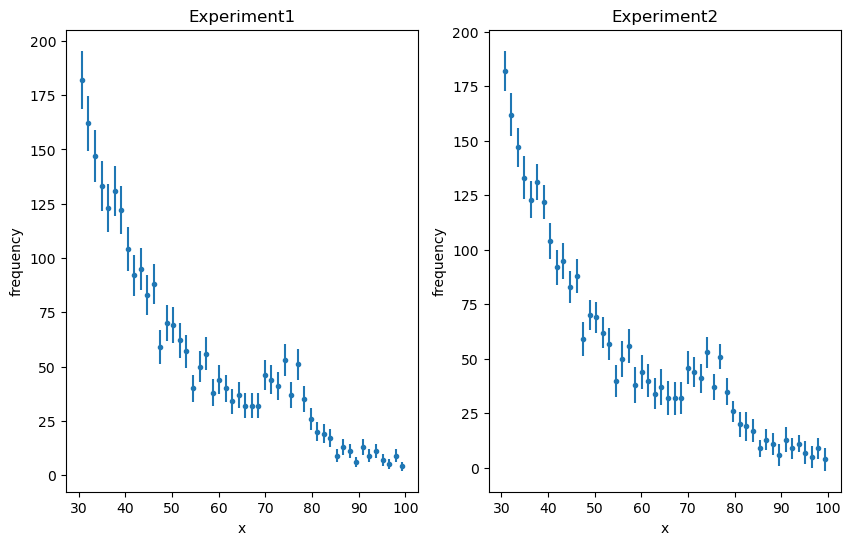

In [4]:
# Plot the histogram data with error bars
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))

ax1.set_title('Experiment1')
ax1.set_xlabel('x')
ax1.set_ylabel('frequency')

ax2.set_title('Experiment2')
ax2.set_xlabel('x')
ax2.set_ylabel('frequency')

ax1.errorbar(x1, y1, yerr=e1, fmt='.')
ax2.errorbar(x1, y1, yerr=e2, fmt='.')


You job for this project will be to develop a simultaneous fit for the two histograms using minuit.  See this week's exercise description for more details.

In [5]:
from scipy.stats import chi2


def gaussian(x, cen, sig):
    return np.exp(-0.5 * ((x - cen) / sig)**2)

def exponential_bg(x, lam):
    return np.exp(-x / lam)

def powerlaw_bg(x, n):
    return np.power(x, n)

def model1(params, x):
    sig = params['sig_amp1'] * gaussian(x, params['mean'], params['sigma'])
    bg = params['bg_amp1'] * exponential_bg(x, params['bg_lam1'])
    return sig + bg

def model2(params, x):
    sig = params['sig_amp2'] * gaussian(x, params['mean'], params['sigma'])
    bg = params['bg_amp2'] * powerlaw_bg(x, params['bg_n2'])
    return sig + bg

def objective(params, x1, y1, e1, x2, y2, e2):
    model_y1 = model1(params, x1)
    residual1 = (y1 - model_y1) / e1
    model_y2 = model2(params, x2)
    residual2 = (y2 - model_y2) / e2
    return np.concatenate((residual1, residual2))

In [6]:
params = Parameters()

params.add('mean', value=75, vary=True)
params.add('sigma', value=4.5, vary=True, min=0.1)

params.add('sig_amp1', value=30, vary=True, min=0)
params.add('bg_amp1', value=80, vary=True, min=0)
params.add('bg_lam1', value=20, vary=True)

params.add('sig_amp2', value=40, vary=True, min=0)
params.add('bg_amp2', value=250000, vary=True, min=0)
params.add('bg_n2', value=-2.2, vary=True)

result = minimize(objective, params, args=(x1, y1, e1, x2, y2, e2))

print(fit_report(result))

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 64
    # data points      = 100
    # variables        = 8
    chi-square         = 76.1675733
    reduced chi-square = 0.82790841
    Akaike info crit   = -11.2234361
    Bayesian info crit = 9.61792540
[[Variables]]
    mean:      74.6039559 +/- 0.40831391 (0.55%) (init = 75)
    sigma:     4.59623201 +/- 0.43065618 (9.37%) (init = 4.5)
    sig_amp1:  26.4275708 +/- 2.91413339 (11.03%) (init = 30)
    bg_amp1:   819.815266 +/- 58.6902260 (7.16%) (init = 80)
    bg_lam1:   19.7234361 +/- 0.60988698 (3.09%) (init = 20)
    sig_amp2:  24.2823626 +/- 2.95005159 (12.15%) (init = 40)
    bg_amp2:   386453.875 +/- 173830.114 (44.98%) (init = 250000)
    bg_n2:    -2.13618611 +/- 0.10788695 (5.05%) (init = -2.2)
[[Correlations]] (unreported correlations are < 0.100)
    C(bg_amp2, bg_n2)    = -0.9985
    C(bg_amp1, bg_lam1)  = -0.9615
    C(sigma, bg_lam1)    = -0.3673
    C(sigma, sig_amp1)   = -0.3274
    C(sigma,

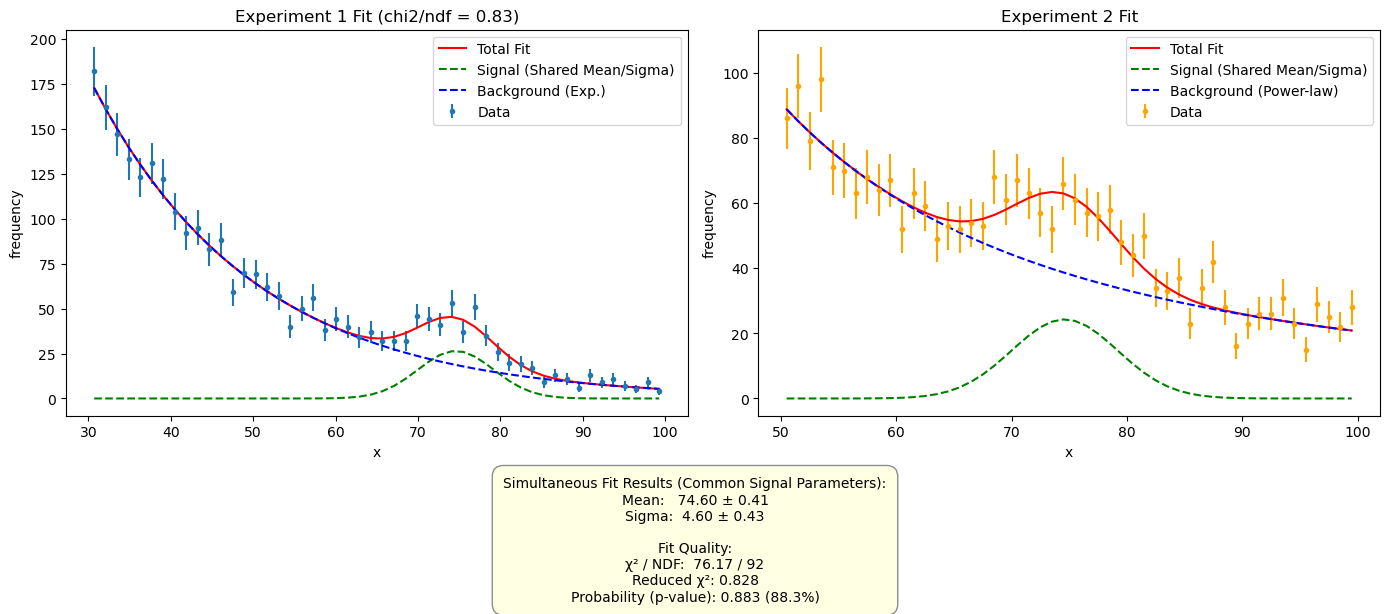

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Experiment 1 plot
ax1.set_title(f'Experiment 1 Fit (chi2/ndf = {result.chisqr/result.nfree:.2f})')
ax1.set_xlabel('x')
ax1.set_ylabel('frequency')
ax1.errorbar(x1, y1, yerr=e1, fmt='.', label='Data', capsize=0)
ax1.plot(x1, model1(result.params, x1), 'r-', label='Total Fit')
sig1 = result.params['sig_amp1'] * gaussian(x1, result.params['mean'], result.params['sigma'])
bg1 = result.params['bg_amp1'] * exponential_bg(x1, result.params['bg_lam1'])
ax1.plot(x1, sig1, 'g--', label='Signal (Shared Mean/Sigma)')
ax1.plot(x1, bg1, 'b--', label='Background (Exp.)')
ax1.legend()

# Experiment 2 plot
ax2.set_title(f'Experiment 2 Fit')
ax2.set_xlabel('x')
ax2.set_ylabel('frequency')
ax2.errorbar(x2, y2, yerr=e2, fmt='.', label='Data', capsize=0, color='orange')
ax2.plot(x2, model2(result.params, x2), 'r-', label='Total Fit')
sig2 = result.params['sig_amp2'] * gaussian(x2, result.params['mean'], result.params['sigma'])
bg2 = result.params['bg_amp2'] * powerlaw_bg(x2, result.params['bg_n2'])
ax2.plot(x2, sig2, 'g--', label='Signal (Shared Mean/Sigma)')
ax2.plot(x2, bg2, 'b--', label='Background (Power-law)')
ax2.legend()

plt.tight_layout(rect=[0, 0.20, 1, 1]) 

# Extract fit results
mean_val = result.params['mean'].value
mean_err = result.params['mean'].stderr
sigma_val = result.params['sigma'].value
sigma_err = result.params['sigma'].stderr
chisqr_val = result.chisqr
ndf_val = result.nfree
prob_val = chi2.sf(chisqr_val, ndf_val)

fit_results_text = (
    f"Simultaneous Fit Results (Common Signal Parameters):\n"
    f"Mean:   {mean_val:.2f} ± {mean_err:.2f}\n"
    f"Sigma:  {sigma_val:.2f} ± {sigma_err:.2f}\n\n"
    f"Fit Quality:\n"
    f"χ² / NDF:  {chisqr_val:.2f} / {ndf_val}\n"
    f"Reduced χ²: {chisqr_val/ndf_val:.3f}\n"
    f"Probability (p-value): {prob_val:.3f} ({prob_val*100:.1f}%)"
)

fig.text(0.5, 0.09, fit_results_text, ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.8', fc='lightyellow', ec='gray', alpha=0.9))

fig.savefig('ex2.pdf', bbox_inches='tight')
plt.show()